**WEEK 2 – DATA SCIENCE WITH PYTHON**

**Project:Exploratory Data Analysis on COVID-19 Dataset**

**Name:** Priya Dharshini R\
**Roll No:** 24BAD092

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"

df = pd.read_csv(url)

df.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN


In [23]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (617667, 61)

Column Names:
['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality', 'excess_mortality_cumulative', 'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'icu_patients', 'icu_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'stringency_index', 'reproduction_rate', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'ne

In [24]:
df[['country', 'date', 'total_cases',
    'total_deaths', 'total_vaccinations']].head()

,country,date,total_cases,total_deaths,total_vaccinations
0,Afghanistan,2020-01-01,NaN,NaN,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN


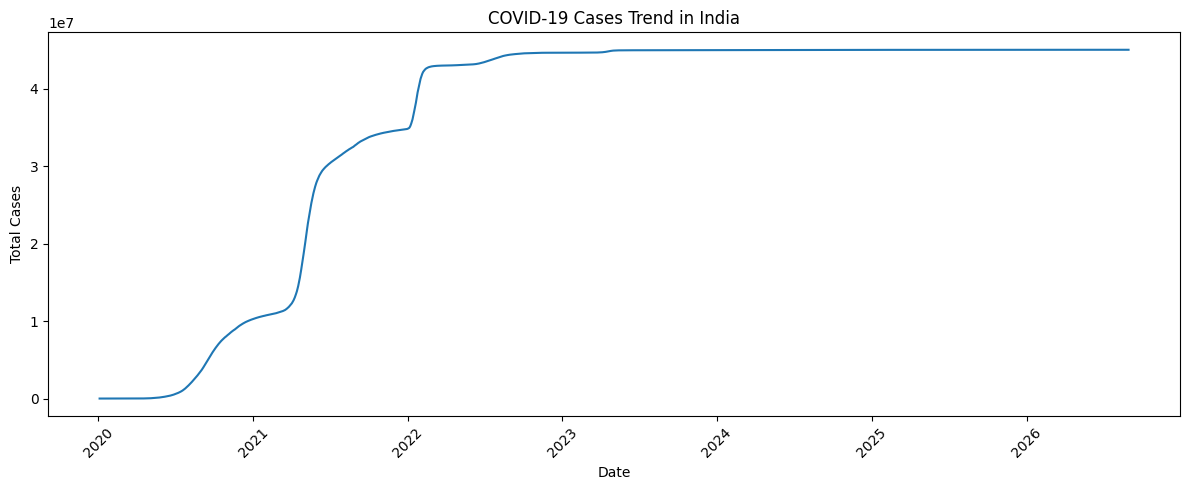

In [25]:
india = df[df['country'] == 'India'].copy()

india['date'] = pd.to_datetime(india['date'])

plt.figure(figsize=(12, 5))

plt.plot(india['date'], india['total_cases'])

plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.title("COVID-19 Cases Trend in India")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
countries = df[df['continent'].notna()]
latest = countries.sort_values('date').groupby('country').tail(1)

top5 = latest.nlargest(5, 'total_cases')
print(top5[['country', 'total_cases']])

              country  total_cases
577203  United States  103436829.0
111933          China   99381761.0
250144          India   45056221.0
190080         France   39061500.0
204678        Germany   38437953.0


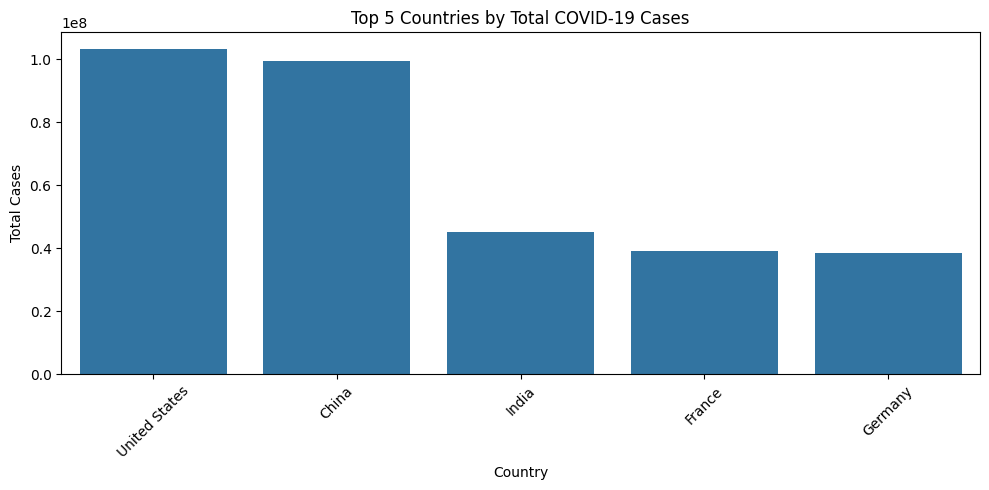

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top5,
    x='country',
    y='total_cases'
)

plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.title("Top 5 Countries by Total COVID-19 Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

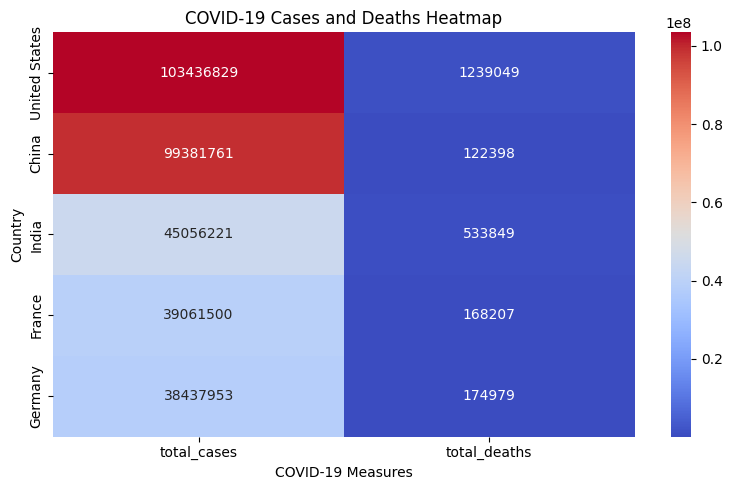

In [27]:
heatmap_data = top5[
    ['country', 'total_cases', 'total_deaths']
].set_index('country')

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='coolwarm'
)

plt.title("COVID-19 Cases and Deaths Heatmap")
plt.xlabel("COVID-19 Measures")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

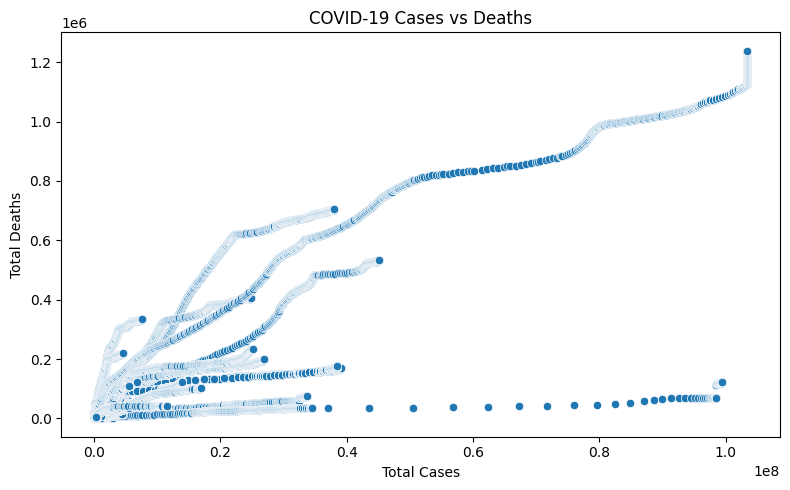

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=countries,
    x='total_cases',
    y='total_deaths'
)

plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")
plt.title("COVID-19 Cases vs Deaths")

plt.tight_layout()
plt.show()